In [1]:
%matplotlib notebook
import torch
import matplotlib.pyplot as plt
from models import *
from datasets import *
from train import *
from visualization import *
from IPython.display import HTML

name = 'MHA'

In [2]:
# Training setup
lr = 1e-4
model = SimpleTransformerModel(input_dim=1)
optim = torch.optim.AdamW(
    params=model.parameters(),
    lr=lr,
    weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=100, gamma=0.5)

In [3]:
# Training loop
processor = Processor(
    x_range=(-8, 8),
    data_dim=(10, 1),
    N=2048,
    ground_truth=topksubset(3, 1),
    model=model,
    epochs=1000,
    criterion=nn.MSELoss(reduction='mean'),
    optimizer=optim,
    seed=42
)

processor.run()
processor.print_summary()
processor.save(f'train_out/{name}_ipynb.h5', output_dir='train_out')

Training: 100%|██████████| 1000/1000 [01:14<00:00, 13.40it/s]



Training complete!
Final losses: Train Loss: 76.572182, Test Loss: 358.536652

TRAINING SUMMARY (from logged logs)

[Configuration]
  Epochs: 1000
  Device: cpu
  Model: SimpleTransformerModel

[Data]
  Train samples: 2048
  Test samples: 4088
  Input shape: torch.Size([2048, 10, 1])

[Loss Statistics]
  Final train loss: 76.572182
  Final test loss:  358.536652
  Best train loss:  76.572182 (epoch 999)
  Best test loss:   358.536652 (epoch 999)

[HDF5 File Structure]
  ├── logs/
  │   ├── x_train: (2048, 10)
  │   ├── y_train: (2048,)
  │   ├── x_test: (4088, 10)
  │   ├── y_test: (4088,)
  │   ├── train_loss: 1000 entries
  │   ├── test_loss: 1000 entries
  │   ├── f_test: (1000, 4088) entries
  │   └── hidden_states: (1000, 4088, 32) entries
  └── metadata/
      ├── x_range: (-8, 8)
      ├── data_dim: (10, 1)
      ├── N: 2048
      ├── ground_truth: function
      ├── model: SimpleTransformerModel
      ├── optimizer: AdamW
      ├── criterion: MSELoss
      ├── scheduler: None


/Users/rlim/Labs/FuncConv-TropNN/train.py:215: UserWarning: Could not save scheduler as array. Saving as string instead.
  warnings.warn(f"Could not save {key} as array. Saving as string instead.")


In [4]:
# Initialize visualizer
visualizer = Visualizer.from_processor_data(processor)
visualizer.print_summary()


TRAINING SUMMARY (from logs)

[Loss Statistics]
  Final train loss: 76.572182
  Final test loss:  358.536652
  Best train loss:  76.572182 (epoch 999)
  Best test loss:   358.536652 (epoch 999)

[HDF5 File Structure]
  ├── logs/
  │   ├── x_train: (2048, 10)
  │   ├── y_train: (2048,)
  │   ├── x_test: (4088, 10)
  │   ├── y_test: (4088,)
  │   ├── train_loss: 1000 entries
  │   ├── test_loss: 1000 entries
  │   ├── f_test: (1000, 4088) entries
  │   └── hidden_states: (1000, 4088, 32) entries
  └── metadata/
      ├── x_range: (-8, 8)
      ├── data_dim: (10, 1)
      ├── N: 2048
      ├── ground_truth: function
      ├── model: SimpleTransformerModel
      ├── optimizer: AdamW
      ├── criterion: MSELoss
      ├── scheduler: None
      └── epochs: 1000



<IPython.core.display.Javascript object>

✓ Loss history saved to 'visualizations/topk-sum/MHA_loss_history.png'


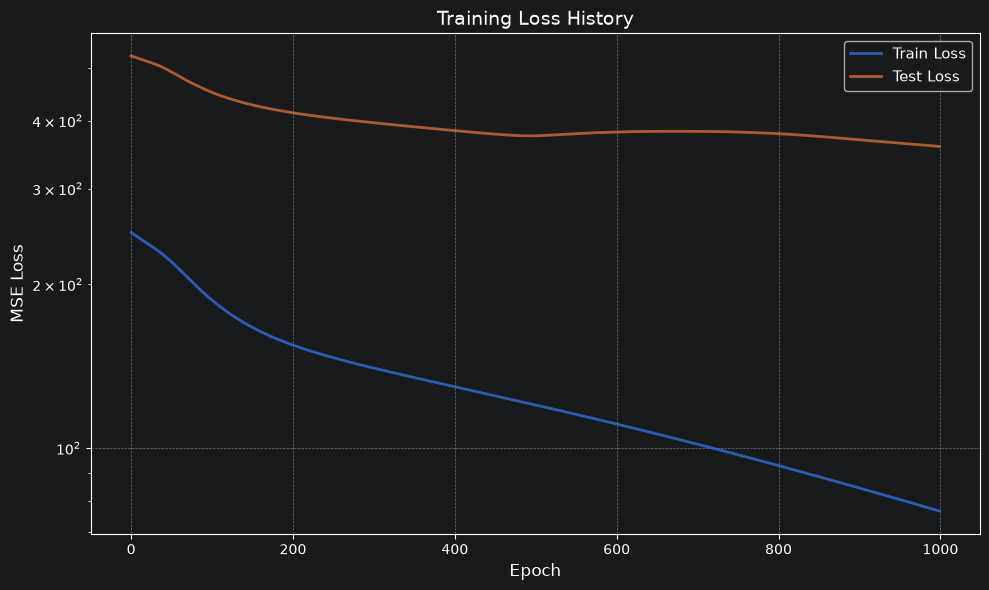

In [10]:
# Loss history
fig = visualizer.plot_loss_history(output_path=f'visualizations/topk-sum/{name}_loss_history.png')
fig

In [11]:
# 1d output space visualization
conv_1d_anim = visualizer.convergence_visualization_1d(output_path=f'visualizations/topk-sum/{name}_loss_history.png')
HTML(conv_1d_anim.to_jshtml())

<IPython.core.display.Javascript object>

✓ 1D convergence animation saved to 'visualizations/topk-sum/MHA_loss_history.png'


AttributeError: 'NoneType' object has no attribute 'remove_callback'

In [ ]:
# pca visualization
pca_fig, pca_anim = visualizer.hidden_layer_visualization(output_path=f'visualizations/topk-sum/{name}_pca.gif')
HTML(pca_anim.to_jshtml())

In [ ]:
# pca procrustes visualization
procrustes_fig, procrustes_anim = visualizer.hidden_layer_procrustes_visualization(pca_epoch='all', output_path=f'visualizations/topk-sum/{name}_pca_procrustes.gif')
HTML(procrustes_anim.to_jshtml())